In [ ]:
from dotenv import load_dotenv
from openai import OpenAI
from graphrunner.runner import GraphNode, GraphRunner, ConditionalNode, LLMNode

In [2]:
client = OpenAI()
def get_response(client: OpenAI, input, instructions=None, model="gpt-5.2"):
    response = client.responses.create(
        model=model,
        instructions=instructions,
        input=input,
        
    )
    text = response.output_text
    usage = response.usage.to_dict()
    return {"response": text, "usage": usage}

In [3]:
def llm_func(user_query):
    response =get_response(
        client=client,
        input=user_query
    )
    return response | {"input_prompt" : user_query}

llm = LLMNode( name = "basicLLM", model_callable=llm_func)

In [4]:
runner = GraphRunner(nodes_dict={"Start": llm}, start_node="Start")

In [5]:
resp = runner.execute({"user_query": "How do I make a margarita"})

In [6]:
runner.state_dict

{'user_query': 'How do I make a margarita',
 'response': 'A classic margarita is simple: tequila + lime + orange liqueur, shaken with ice.\n\n### Classic Margarita (1 drink)\n**Ingredients**\n- 2 oz (60 ml) tequila (blanco is most common)\n- 1 oz (30 ml) fresh lime juice\n- 3/4 oz (22 ml) orange liqueur (Cointreau/Triple Sec)\n- 1/4 oz (7 ml) simple syrup or agave (optional, to taste)\n- Ice\n- Salt for rim (optional)\n\n**Steps**\n1. **Salt the rim (optional):** Run a lime wedge around the rim, dip in salt.\n2. **Shake:** Add tequila, lime juice, orange liqueur (and sweetener if using) to a shaker with ice. Shake hard ~10–15 seconds.\n3. **Serve:** Strain into a **rocks glass over fresh ice** (on the rocks) or into a **chilled coupe** (up).\n4. **Garnish:** Lime wheel or wedge.\n\n### Easy adjustments\n- **Sweeter:** add a bit more agave/simple.\n- **Tarter/stronger:** reduce sweetener or bump tequila to 2.5 oz.\n- **Tommy’s Margarita (no orange liqueur):** 2 oz tequila + 1 oz lime + 

In [7]:
resp_2 =runner.execute({"user_query": "What about a strawberry one"})

In [8]:
resp_2

{'response': '### Strawberry Margarita (fresh, 1 drink)\n\n**Ingredients**\n- 2 oz (60 ml) tequila (blanco)\n- 1 oz (30 ml) fresh lime juice\n- 3/4 oz (22 ml) orange liqueur (Cointreau/Triple Sec) *or* 1/2 oz if you want it less sweet\n- 1/2–3/4 oz (15–22 ml) agave or simple syrup (to taste)\n- 3–5 strawberries (about 3–4 oz / 85–115 g), hulled  \n  *(or 1–1.5 oz strawberry purée)*\n- Ice\n- Optional: salt or **tajín** rim\n\n**Steps**\n1. **Prep glass (optional):** Rim with lime, dip in salt/tajín.\n2. **Blend or shake:**\n   - **Shaken (best texture, less watery):** Muddle strawberries in a shaker, add tequila, lime, orange liqueur, sweetener, and ice. Shake hard 10–15 sec.\n   - **Blended (frozen):** Add everything to a blender with 1–1.5 cups ice and blend until slushy.\n3. **Serve:** Strain over fresh ice (shaken) or pour (frozen). Garnish with a strawberry or lime.\n\n**Quick tips**\n- If your strawberries aren’t very sweet, add a touch more agave.\n- Want it brighter? Add a pinc

In [9]:
resp_3 = runner.execute({"user_query":"Can I make a frozen one using a Ninja Slushi"})

In [11]:
print(resp_3["response"])

Yes. A Ninja Slushi works great for a **frozen strawberry margarita**—you just want the mix **cold and balanced** so it freezes into a smooth slush (not a hard block or a runny drink).

## Ninja Slushi Frozen Strawberry Margarita (about 2–3 servings)
**Ingredients**
- 6 oz (180 ml) tequila (blanco)
- 3 oz (90 ml) fresh lime juice
- 2–3 oz (60–90 ml) orange liqueur (Cointreau/Triple Sec)  
  *(use 2 oz if you like it less sweet)*
- 2–3 oz (60–90 ml) agave syrup or simple syrup (to taste)
- 8–10 oz (225–285 g) strawberries (fresh or thawed frozen)
- 4–6 oz (120–180 ml) cold water **or** ice (only if needed to thin)

## Steps (Slushi method)
1. **Make it very cold first:** Add everything to a blender (or use an immersion blender) and blend until smooth.
2. **Chill the base:** Refrigerate 30–60 minutes (or 15 minutes in the freezer, stirring once). Cold base slushes faster and smoother.
3. **Pour into the Ninja Slushi** up to the max fill line.
4. Select **Slush** (or the closest frozen/sl

In [16]:
from markdown import markdown

In [20]:
print(markdown(resp_3["response"]))

<p>Yes. A Ninja Slushi works great for a <strong>frozen strawberry margarita</strong>—you just want the mix <strong>cold and balanced</strong> so it freezes into a smooth slush (not a hard block or a runny drink).</p>
<h2>Ninja Slushi Frozen Strawberry Margarita (about 2–3 servings)</h2>
<p><strong>Ingredients</strong>
- 6 oz (180 ml) tequila (blanco)
- 3 oz (90 ml) fresh lime juice
- 2–3 oz (60–90 ml) orange liqueur (Cointreau/Triple Sec)<br />
<em>(use 2 oz if you like it less sweet)</em>
- 2–3 oz (60–90 ml) agave syrup or simple syrup (to taste)
- 8–10 oz (225–285 g) strawberries (fresh or thawed frozen)
- 4–6 oz (120–180 ml) cold water <strong>or</strong> ice (only if needed to thin)</p>
<h2>Steps (Slushi method)</h2>
<ol>
<li><strong>Make it very cold first:</strong> Add everything to a blender (or use an immersion blender) and blend until smooth.</li>
<li><strong>Chill the base:</strong> Refrigerate 30–60 minutes (or 15 minutes in the freezer, stirring once). Cold base slushes fa

In [21]:
from IPython.display import Markdown

In [22]:
Markdown(resp_3["response"])

Yes. A Ninja Slushi works great for a **frozen strawberry margarita**—you just want the mix **cold and balanced** so it freezes into a smooth slush (not a hard block or a runny drink).

## Ninja Slushi Frozen Strawberry Margarita (about 2–3 servings)
**Ingredients**
- 6 oz (180 ml) tequila (blanco)
- 3 oz (90 ml) fresh lime juice
- 2–3 oz (60–90 ml) orange liqueur (Cointreau/Triple Sec)  
  *(use 2 oz if you like it less sweet)*
- 2–3 oz (60–90 ml) agave syrup or simple syrup (to taste)
- 8–10 oz (225–285 g) strawberries (fresh or thawed frozen)
- 4–6 oz (120–180 ml) cold water **or** ice (only if needed to thin)

## Steps (Slushi method)
1. **Make it very cold first:** Add everything to a blender (or use an immersion blender) and blend until smooth.
2. **Chill the base:** Refrigerate 30–60 minutes (or 15 minutes in the freezer, stirring once). Cold base slushes faster and smoother.
3. **Pour into the Ninja Slushi** up to the max fill line.
4. Select **Slush** (or the closest frozen/slush setting) and let it run until thick.
5. **Taste & adjust:**
   - Too tart/boozy: add a bit more agave/simple.
   - Too thick: add a splash of cold water.
   - Too thin: add more strawberries or chill longer and re-spin.

## Rim / garnish (optional)
- Rim glass with **tajín** (great with strawberry) or salt.
- Garnish with a strawberry or lime wheel.

If you tell me your **Ninja Slushi model** (or the mode names on it) and whether your strawberries are **fresh or frozen**, I can give tighter amounts so it hits the perfect slush texture on your machine.

In [25]:
runner.state_dict["message_history"]

[('How do I make a margarita',
  'A classic margarita is simple: tequila + lime + orange liqueur, shaken with ice.\n\n### Classic Margarita (1 drink)\n**Ingredients**\n- 2 oz (60 ml) tequila (blanco is most common)\n- 1 oz (30 ml) fresh lime juice\n- 3/4 oz (22 ml) orange liqueur (Cointreau/Triple Sec)\n- 1/4 oz (7 ml) simple syrup or agave (optional, to taste)\n- Ice\n- Salt for rim (optional)\n\n**Steps**\n1. **Salt the rim (optional):** Run a lime wedge around the rim, dip in salt.\n2. **Shake:** Add tequila, lime juice, orange liqueur (and sweetener if using) to a shaker with ice. Shake hard ~10–15 seconds.\n3. **Serve:** Strain into a **rocks glass over fresh ice** (on the rocks) or into a **chilled coupe** (up).\n4. **Garnish:** Lime wheel or wedge.\n\n### Easy adjustments\n- **Sweeter:** add a bit more agave/simple.\n- **Tarter/stronger:** reduce sweetener or bump tequila to 2.5 oz.\n- **Tommy’s Margarita (no orange liqueur):** 2 oz tequila + 1 oz lime + 1/2–3/4 oz agave.\n\nIf 

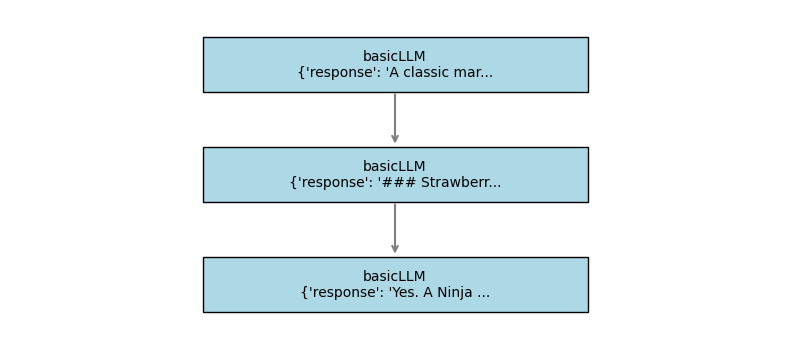

In [26]:
runner.matplotlib_trace()

In [27]:
runner.trace_log

[{'step_num': 1,
  'name': 'basicLLM',
  'node_input': {'user_query': 'How do I make a margarita'},
  'node_output': {'response': 'A classic margarita is simple: tequila + lime + orange liqueur, shaken with ice.\n\n### Classic Margarita (1 drink)\n**Ingredients**\n- 2 oz (60 ml) tequila (blanco is most common)\n- 1 oz (30 ml) fresh lime juice\n- 3/4 oz (22 ml) orange liqueur (Cointreau/Triple Sec)\n- 1/4 oz (7 ml) simple syrup or agave (optional, to taste)\n- Ice\n- Salt for rim (optional)\n\n**Steps**\n1. **Salt the rim (optional):** Run a lime wedge around the rim, dip in salt.\n2. **Shake:** Add tequila, lime juice, orange liqueur (and sweetener if using) to a shaker with ice. Shake hard ~10–15 seconds.\n3. **Serve:** Strain into a **rocks glass over fresh ice** (on the rocks) or into a **chilled coupe** (up).\n4. **Garnish:** Lime wheel or wedge.\n\n### Easy adjustments\n- **Sweeter:** add a bit more agave/simple.\n- **Tarter/stronger:** reduce sweetener or bump tequila to 2.5 oz.\

In [28]:
prompt_format = "You are an expert mixologist trying to answer questions for an aspiring bartender. This bartender has asked you {user_query}"

In [37]:
prompt_format = """
You are a senior cocktail bar manager training a new bartender.
Answer concisely.
Use professional terminology.
Focus on technique and balance.
Avoid beginner-level explanations.

Respond in this format:
- Spec
- Technique Notes
- Common Mistakes
- Pro Tip

Question: {user_query}
"""

In [38]:
bar_llm = LLMNode(name="bartender", model_callable=llm_func, prompt_template=prompt_format)
runner_bar = GraphRunner({"start": bar_llm}, "start")

In [39]:
respnse = runner_bar.execute({"user_query":"How do you make a margarita"})

In [40]:
Markdown(respnse["response"])

- **Spec**
  - 50 ml 100% agave blanco tequila  
  - 25 ml fresh lime juice  
  - 20 ml orange liqueur (Curaçao/Cointreau)  
  - 5–10 ml agave syrup (optional, to balance)  
  - 1 small pinch fine salt (optional, in the tin)  
  - Garnish: lime wheel; half-salt rim (kosher salt)

- **Technique Notes**
  - Build in shaker; add ice (hard, cold cubes), shake hard 8–12 seconds for full aeration and proper dilution.
  - Taste balance: target bright acidity with a clean agave finish; adjust sweetness with agave in 2.5 ml increments.
  - Rim: half-rim only—wipe with lime, dip lightly in salt to avoid salinity dominating the first sip.
  - Strain: double strain into a chilled rocks glass over fresh ice (or serve “up” in a chilled coupe).

- **Common Mistakes**
  - Using sour mix or bottled lime—kills acidity and aromatics.
  - Overpouring orange liqueur, turning it into a sweet citrus cocktail instead of tequila-forward.
  - Under-shaking (watery, disjointed) or over-diluting with wet/old ice.
  - Full heavy salt rim that overwhelms balance and masks agave.

- **Pro Tip**
  - If limes are especially sharp, keep the spec but add 5 ml agave and a pinch of salt in the shaker; it rounds acidity and makes the tequila read more vividly without increasing perceived sweetness.

In [35]:
resp["response"]

'A classic margarita is simple: tequila + lime + orange liqueur, shaken with ice.\n\n### Classic Margarita (1 drink)\n**Ingredients**\n- 2 oz (60 ml) tequila (blanco is most common)\n- 1 oz (30 ml) fresh lime juice\n- 3/4 oz (22 ml) orange liqueur (Cointreau/Triple Sec)\n- 1/4 oz (7 ml) simple syrup or agave (optional, to taste)\n- Ice\n- Salt for rim (optional)\n\n**Steps**\n1. **Salt the rim (optional):** Run a lime wedge around the rim, dip in salt.\n2. **Shake:** Add tequila, lime juice, orange liqueur (and sweetener if using) to a shaker with ice. Shake hard ~10–15 seconds.\n3. **Serve:** Strain into a **rocks glass over fresh ice** (on the rocks) or into a **chilled coupe** (up).\n4. **Garnish:** Lime wheel or wedge.\n\n### Easy adjustments\n- **Sweeter:** add a bit more agave/simple.\n- **Tarter/stronger:** reduce sweetener or bump tequila to 2.5 oz.\n- **Tommy’s Margarita (no orange liqueur):** 2 oz tequila + 1 oz lime + 1/2–3/4 oz agave.\n\nIf you tell me what tequila/liqueur 

In [36]:
runner_bar.state_dict

{'user_query': 'How do you make a margarita',
 'response': 'A classic margarita is simple: tequila, fresh lime, and orange liqueur, balanced with a touch of sweetness and plenty of cold dilution.\n\n## Classic Margarita (recommended spec)\n**Ingredients**\n- 2 oz (60 ml) **tequila blanco**\n- 1 oz (30 ml) **fresh lime juice**\n- 3/4 oz (22.5 ml) **triple sec/Cointreau**\n- 1/4–1/2 oz (7.5–15 ml) **agave syrup** (optional, to taste—depends on how sweet your orange liqueur is)\n- **Kosher salt** for the rim (optional)\n\n**Method**\n1. **Salt the rim (optional):** Run a lime wedge around the rim, dip into salt (half-rim is nice for guests).\n2. **Shake:** Add tequila, lime, orange liqueur (and agave if using) to a shaker with plenty of ice.\n3. **Shake hard** 10–15 seconds until well-chilled.\n4. **Strain:**  \n   - Over fresh ice in a **rocks glass** for a “on-the-rocks” margarita, or  \n   - **Up** into a chilled coupe (no ice).\n5. **Garnish:** Lime wheel or wedge.\n\n## Quick balanci